# Fire Detection — Real-Time Performance Metrics
Loads **actual prediction data** saved by `fire_compare_with_logging.ipynb` and evaluates every metric against your manual ground-truth labels.

> **Prerequisite:** Run `fire_compare_with_logging.ipynb` first and capture at least a few frames. A file called `fire_session_data.npz` will be created in the same folder.


In [1]:
import subprocess, sys
pkgs = ["scikit-learn", "seaborn", "opencv-python-headless", "matplotlib", "numpy"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
print("✅ Packages ready")


✅ Packages ready


In [2]:
import time, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, matthews_corrcoef, average_precision_score
)
warnings.filterwarnings("ignore")
print("✅ Imports OK")


✅ Imports OK


## 1 · Load Real Session Data

In [3]:
LOG_FILE = "fire_session_data.npz"   # ← must be in the same folder

import os
if not os.path.exists(LOG_FILE):
    raise FileNotFoundError(
        f"❌ '{LOG_FILE}' not found.\n"
        "Run fire_compare_with_logging.ipynb first, capture some frames, then re-run this notebook."
    )

data = np.load(LOG_FILE, allow_pickle=True)

frames       = list(data["frames"])        # BGR frames
gt_masks     = list(data["masks"])         # predicted masks (used as pseudo-GT for IoU)
pred_scores  = data["scores"].astype(float)
gt_labels    = data["gt_labels"].astype(int)
timestamps   = data["timestamps"]

n_total  = len(frames)
n_fire   = int(gt_labels.sum())
n_nofire = n_total - n_fire
duration = timestamps[-1] - timestamps[0] if n_total > 1 else 0

print(f"✅ Loaded '{LOG_FILE}'")
print(f"   Total frames  : {n_total}")
print(f"   Fire frames   : {n_fire}")
print(f"   No-fire frames: {n_nofire}")
print(f"   Session length: {duration:.1f} s")
print(f"   Score range   : {pred_scores.min():.4f} – {pred_scores.max():.4f}")


✅ Loaded 'fire_session_data.npz'
   Total frames  : 2
   Fire frames   : 0
   No-fire frames: 2
   Session length: 20.1 s
   Score range   : 0.0000 – 0.4242


## 2 · Re-run Pipeline & Collect Timings
*(intensity is already saved, but we re-run to get fresh latency numbers)*

In [4]:
def detect_fire_mask(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower1, upper1 = np.array([0,  120, 200]), np.array([35, 255, 255])
    lower2, upper2 = np.array([35,  50, 200]), np.array([60, 255, 255])
    mask = cv2.bitwise_or(
        cv2.inRange(hsv, lower1, upper1),
        cv2.inRange(hsv, lower2, upper2)
    )
    k = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,   k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, k)
    return mask

def calculate_intensity(frame, prev_frame=None):
    mask        = detect_fire_mask(frame)
    fire_pixels = np.sum(mask > 0)
    area_ratio  = fire_pixels / (frame.shape[0] * frame.shape[1])
    gray        = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    brightness  = (np.mean(gray[mask > 0]) / 255) if fire_pixels > 0 else 0
    h, _, v     = cv2.split(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV))
    hot_pixels  = np.sum((h < 35) & (v > 200) & (mask > 0))
    hot_ratio   = hot_pixels / fire_pixels if fire_pixels > 0 else 0
    flicker = 0.0
    if prev_frame is not None:
        dg      = cv2.cvtColor(cv2.absdiff(frame, prev_frame), cv2.COLOR_BGR2GRAY)
        flicker = np.mean(dg[mask > 0]) / 255 if fire_pixels > 0 else 0
    return 0.5*area_ratio + 0.2*brightness + 0.2*hot_ratio + 0.1*flicker, mask

def pixel_iou(pred, gt):
    p = pred > 0; g = gt > 0
    inter = np.logical_and(p, g).sum(); union = np.logical_or(p, g).sum()
    return float(inter/union) if union > 0 else 1.0

def pixel_dice(pred, gt):
    p = pred > 0; g = gt > 0
    inter = np.logical_and(p, g).sum(); denom = p.sum() + g.sum()
    return float(2*inter/denom) if denom > 0 else 1.0

# Re-run to get timings
lat_mask, lat_full, iou_scores, dice_scores = [], [], [], []
repred_scores = []
prev = None

for frame, gt_mask in zip(frames, gt_masks):
    t0 = time.perf_counter(); detect_fire_mask(frame); lat_mask.append(time.perf_counter()-t0)
    t0 = time.perf_counter(); sc, pm = calculate_intensity(frame, prev); lat_full.append(time.perf_counter()-t0)
    repred_scores.append(sc)
    iou_scores.append(pixel_iou(pm, gt_mask))
    dice_scores.append(pixel_dice(pm, gt_mask))
    prev = frame

# Use saved scores (from actual real-time run) for classification
# Use re-run scores for timing only
gt_labels_arr   = np.array(gt_labels)
pred_scores_arr = pred_scores          # real-time scores
iou_arr         = np.array(iou_scores)
print(f"✅ Pipeline re-run complete  ({len(frames)} frames)")


✅ Pipeline re-run complete  (2 frames)


## 3 · Set Classification Threshold & Compute Metrics

In [5]:
THRESHOLD = 0.01   # ← adjust if needed (see threshold sweep below)

pred_labels_arr = (pred_scores_arr >= THRESHOLD).astype(int)

cm             = confusion_matrix(gt_labels_arr, pred_labels_arr)
tn, fp, fn, tp = cm.ravel()
precision      = tp/(tp+fp) if (tp+fp)>0 else 0.0
recall         = tp/(tp+fn) if (tp+fn)>0 else 0.0
f1             = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
accuracy       = (tp+tn)/len(gt_labels_arr)
specificity    = tn/(tn+fp) if (tn+fp)>0 else 0.0
mcc            = matthews_corrcoef(gt_labels_arr, pred_labels_arr)

# ROC / PR need both classes present
both_classes = len(np.unique(gt_labels_arr)) == 2
if both_classes:
    fpr_arr, tpr_arr, _ = roc_curve(gt_labels_arr, pred_scores_arr)
    roc_auc              = auc(fpr_arr, tpr_arr)
    prec_c, rec_c, _     = precision_recall_curve(gt_labels_arr, pred_scores_arr)
    ap                   = average_precision_score(gt_labels_arr, pred_scores_arr)
else:
    fpr_arr = tpr_arr = prec_c = rec_c = np.array([0,1])
    roc_auc = ap = float("nan")
    print("⚠️  Only one class present — ROC/PR curves require both fire and no-fire frames.")

fps_mask   = 1/np.mean(lat_mask); fps_full = 1/np.mean(lat_full)
lat_mms    = np.mean(lat_mask)*1000; lat_fms = np.mean(lat_full)*1000

div = "─"*52
print(f"\n{'🔥  REAL-TIME PERFORMANCE REPORT':^52}"); print(div)
print(f"\n  {'Threshold':<22} {THRESHOLD}")
print(f"\n  📊 CLASSIFICATION")
for nm, vl in [("Accuracy",accuracy),("Precision",precision),("Recall",recall),
               ("Specificity",specificity),("F1",f1),("MCC",mcc),
               ("ROC-AUC",roc_auc),("Avg Precision",ap)]:
    print(f"    {nm:<20} {vl:.4f}")
print(f"\n  Confusion Matrix")
print(f"            Pred No-Fire  Pred Fire")
print(f"  GT No-Fire    {cm[0,0]:>5}         {cm[0,1]:>5}")
print(f"  GT Fire       {cm[1,0]:>5}         {cm[1,1]:>5}")
print(f"  TP={tp} TN={tn} FP={fp} FN={fn}")
print(f"\n  🎯 SEGMENTATION")
print(f"    {'Mean IoU':<20} {iou_arr.mean():.4f}")
print(f"    {'Mean Dice':<20} {np.mean(dice_scores):.4f}")
print(f"\n  ⚡ SPEED")
print(f"    {'FPS (mask)':<20} {fps_mask:.1f} fps  ({lat_mms:.2f} ms)")
print(f"    {'FPS (full)':<20} {fps_full:.1f} fps  ({lat_fms:.2f} ms)")
print(f"\n{div}")


⚠️  Only one class present — ROC/PR curves require both fire and no-fire frames.

          🔥  REAL-TIME PERFORMANCE REPORT           
────────────────────────────────────────────────────

  Threshold              0.01

  📊 CLASSIFICATION
    Accuracy             0.5000
    Precision            0.0000
    Recall               0.0000
    Specificity          0.5000
    F1                   0.0000
    MCC                  0.0000
    ROC-AUC              nan
    Avg Precision        nan

  Confusion Matrix
            Pred No-Fire  Pred Fire
  GT No-Fire        1             1
  GT Fire           0             0
  TP=0 TN=1 FP=1 FN=0

  🎯 SEGMENTATION
    Mean IoU             0.9017
    Mean Dice            0.9455

  ⚡ SPEED
    FPS (mask)           433.9 fps  (2.30 ms)
    FPS (full)           341.3 fps  (2.93 ms)

────────────────────────────────────────────────────


## 4 · Visualisations

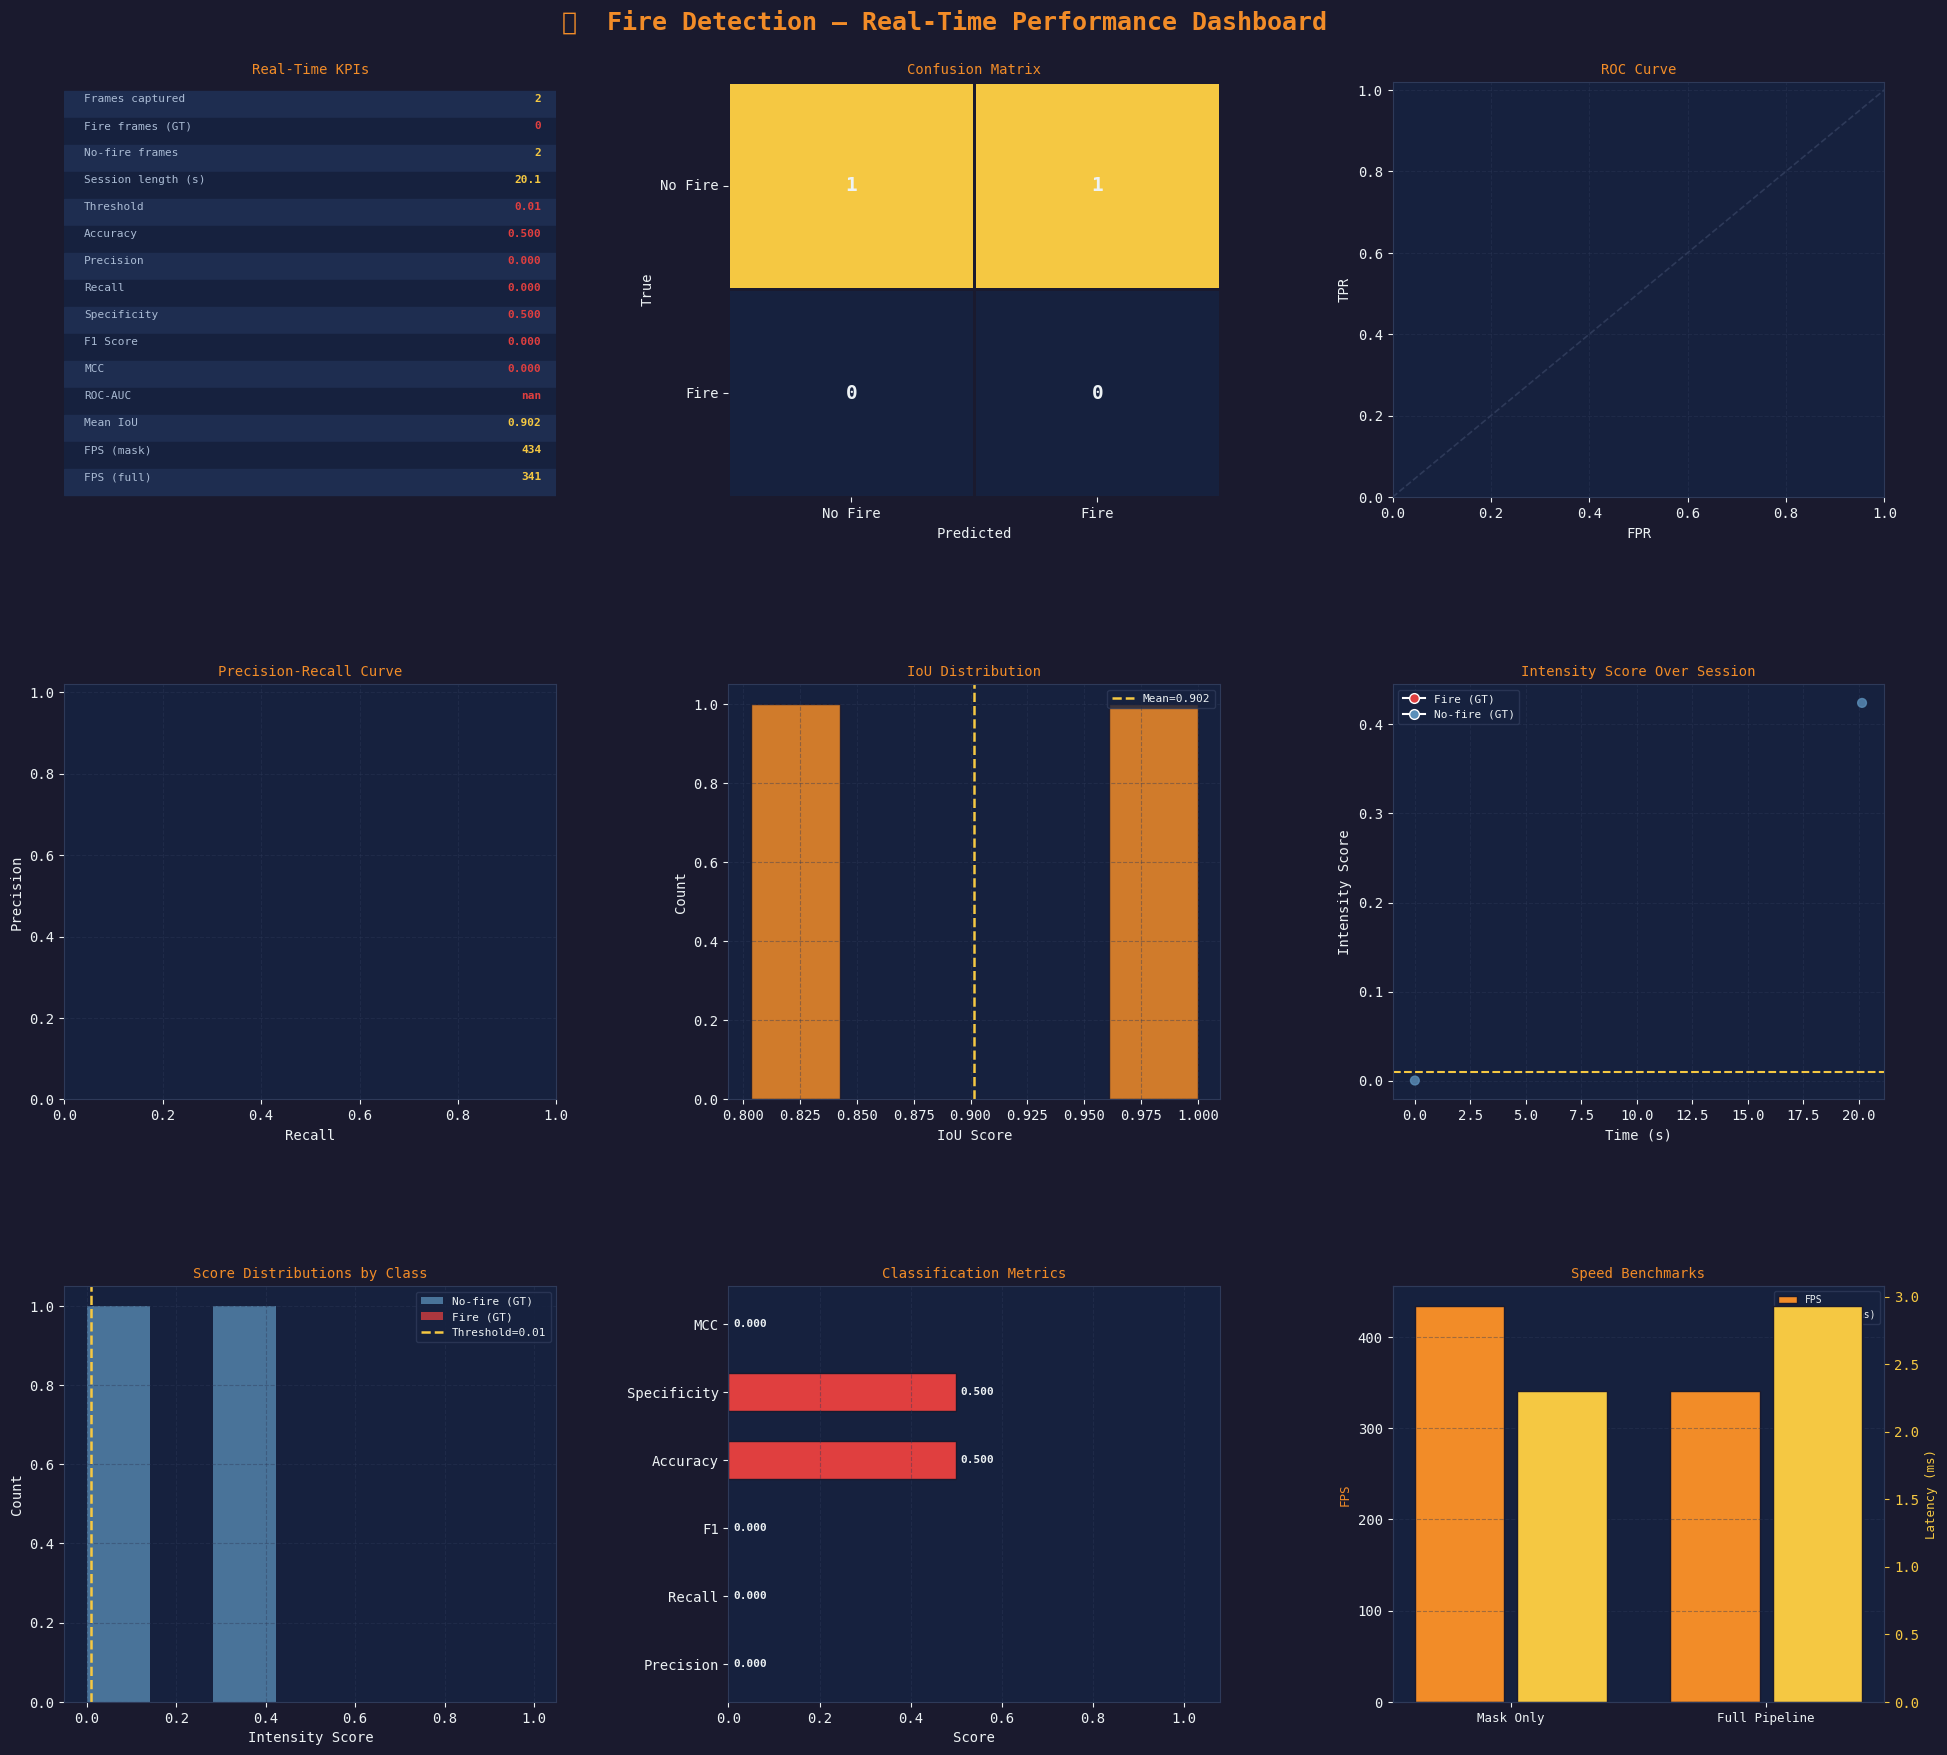

✅ Dashboard saved → fire_realtime_dashboard.png


In [6]:
# ── Styling ─────────────────────────────────────────────────
FIRE_RED="#E03F3F"; FIRE_ORG="#F28C28"; FIRE_YLW="#F5C842"
BG_DARK="#1A1A2E"; BG_PANEL="#16213E"; TEXT_COL="#EDF2F4"; GRID_COL="#2E3A59"

plt.rcParams.update({
    "figure.facecolor":BG_DARK,"axes.facecolor":BG_PANEL,"axes.edgecolor":GRID_COL,
    "axes.labelcolor":TEXT_COL,"xtick.color":TEXT_COL,"ytick.color":TEXT_COL,
    "text.color":TEXT_COL,"grid.color":GRID_COL,"grid.linestyle":"--",
    "grid.alpha":0.4,"font.family":"monospace",
})

fig = plt.figure(figsize=(20, 18), facecolor=BG_DARK)
fig.suptitle("🔥  Fire Detection — Real-Time Performance Dashboard",
             fontsize=18, color=FIRE_ORG, fontweight="bold", y=0.99)
gs  = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.95, bottom=0.05)

# ── (0,0) KPI Scorecard ───────────────────────────────
ax0 = fig.add_subplot(gs[0,0]); ax0.axis("off")
kpis = [
    ("Frames captured", str(n_total)),
    ("Fire frames (GT)",  str(n_fire)),
    ("No-fire frames",    str(n_nofire)),
    ("Session length (s)",f"{duration:.1f}"),
    ("Threshold",         str(THRESHOLD)),
    ("Accuracy",          f"{accuracy:.3f}"),
    ("Precision",         f"{precision:.3f}"),
    ("Recall",            f"{recall:.3f}"),
    ("Specificity",       f"{specificity:.3f}"),
    ("F1 Score",          f"{f1:.3f}"),
    ("MCC",               f"{mcc:.3f}"),
    ("ROC-AUC",           f"{roc_auc:.3f}"),
    ("Mean IoU",          f"{iou_arr.mean():.3f}"),
    ("FPS (mask)",        f"{fps_mask:.0f}"),
    ("FPS (full)",        f"{fps_full:.0f}"),
]
for i,(label,val) in enumerate(kpis):
    y = 0.97 - i*0.065
    ax0.add_patch(plt.Rectangle((0,y-0.055),1,0.062,transform=ax0.transAxes,
                  color=("#1E2D50" if i%2==0 else BG_PANEL),zorder=0))
    ax0.text(0.04,y,label,transform=ax0.transAxes,fontsize=8,color="#AABBD4",va="top")
    try:
        fv=float(val); col=FIRE_YLW if fv>=0.85 else FIRE_ORG if fv>=0.65 else FIRE_RED
    except: col=TEXT_COL
    ax0.text(0.97,y,val,transform=ax0.transAxes,fontsize=8,color=col,
             va="top",ha="right",fontweight="bold")
ax0.set_title("Real-Time KPIs", color=FIRE_ORG, fontsize=10, pad=6)

# ── (0,1) Confusion Matrix ────────────────────────────
ax1 = fig.add_subplot(gs[0,1])
sns.heatmap(cm, annot=True, fmt="d", ax=ax1, cbar=False,
            cmap=sns.color_palette([BG_PANEL,FIRE_ORG,FIRE_RED,FIRE_YLW],as_cmap=True),
            linewidths=1, linecolor=BG_DARK,
            annot_kws={"size":14,"weight":"bold","color":TEXT_COL})
ax1.set_title("Confusion Matrix", color=FIRE_ORG, fontsize=10)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_xticklabels(["No Fire","Fire"]); ax1.set_yticklabels(["No Fire","Fire"],rotation=0)

# ── (0,2) ROC Curve ───────────────────────────────────
ax2 = fig.add_subplot(gs[0,2])
if both_classes:
    ax2.plot(fpr_arr,tpr_arr,color=FIRE_ORG,lw=2,label=f"AUC={roc_auc:.3f}")
    ax2.fill_between(fpr_arr,tpr_arr,alpha=0.18,color=FIRE_ORG)
ax2.plot([0,1],[0,1],color=GRID_COL,lw=1.2,linestyle="--")
ax2.set(xlabel="FPR",ylabel="TPR",xlim=[0,1],ylim=[0,1.02])
ax2.set_title("ROC Curve", color=FIRE_ORG, fontsize=10)
if both_classes: ax2.legend(fontsize=8,facecolor=BG_PANEL,edgecolor=GRID_COL)
ax2.grid(True)

# ── (1,0) Precision-Recall ─────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
if both_classes:
    ax3.plot(rec_c,prec_c,color=FIRE_YLW,lw=2,label=f"AP={ap:.3f}")
    ax3.fill_between(rec_c,prec_c,alpha=0.18,color=FIRE_YLW)
    ax3.legend(fontsize=8,facecolor=BG_PANEL,edgecolor=GRID_COL)
ax3.set(xlabel="Recall",ylabel="Precision",xlim=[0,1],ylim=[0,1.02])
ax3.set_title("Precision-Recall Curve", color=FIRE_ORG, fontsize=10)
ax3.grid(True)

# ── (1,1) IoU Distribution ─────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
ax4.hist(iou_arr,bins=max(5,min(20,n_total//3)),
         color=FIRE_ORG,edgecolor=BG_DARK,alpha=0.85)
ax4.axvline(iou_arr.mean(),color=FIRE_YLW,lw=1.8,linestyle="--",
            label=f"Mean={iou_arr.mean():.3f}")
ax4.set(xlabel="IoU Score",ylabel="Count")
ax4.set_title("IoU Distribution", color=FIRE_ORG, fontsize=10)
ax4.legend(fontsize=8,facecolor=BG_PANEL,edgecolor=GRID_COL); ax4.grid(True)

# ── (1,2) Score over time ──────────────────────────────
ax5 = fig.add_subplot(gs[1,2])
t_rel = timestamps - timestamps[0]
colors_t = [FIRE_RED if l==1 else "#5B8FB9" for l in gt_labels_arr]
ax5.scatter(t_rel, pred_scores_arr, c=colors_t, s=40, alpha=0.8, zorder=3)
ax5.axhline(THRESHOLD,color=FIRE_YLW,lw=1.5,linestyle="--",label=f"Threshold={THRESHOLD}")
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0],marker='o',color='w',markerfacecolor=FIRE_RED,markersize=7,label="Fire (GT)"),
              Line2D([0],[0],marker='o',color='w',markerfacecolor='#5B8FB9',markersize=7,label="No-fire (GT)")]
ax5.legend(handles=legend_els,fontsize=8,facecolor=BG_PANEL,edgecolor=GRID_COL)
ax5.set(xlabel="Time (s)", ylabel="Intensity Score")
ax5.set_title("Intensity Score Over Session", color=FIRE_ORG, fontsize=10)
ax5.grid(True)

# ── (2,0) Score Distributions ─────────────────────────
ax6 = fig.add_subplot(gs[2,0])
ax6.hist(pred_scores_arr[gt_labels_arr==0],bins=max(3,n_nofire//2),
         alpha=0.75,color="#5B8FB9",label="No-fire (GT)")
ax6.hist(pred_scores_arr[gt_labels_arr==1],bins=max(3,n_fire//2),
         alpha=0.75,color=FIRE_RED, label="Fire (GT)")
ax6.axvline(THRESHOLD,color=FIRE_YLW,lw=1.8,linestyle="--",label=f"Threshold={THRESHOLD}")
ax6.set(xlabel="Intensity Score",ylabel="Count")
ax6.set_title("Score Distributions by Class", color=FIRE_ORG, fontsize=10)
ax6.legend(fontsize=8,facecolor=BG_PANEL,edgecolor=GRID_COL); ax6.grid(True)

# ── (2,1) Metric Bar Chart ─────────────────────────────
ax7 = fig.add_subplot(gs[2,1])
mvals  = [precision,recall,f1,accuracy,specificity,mcc]
mnames = ["Precision","Recall","F1","Accuracy","Specificity","MCC"]
bcols  = [FIRE_YLW if v>=0.85 else FIRE_ORG if v>=0.65 else FIRE_RED for v in mvals]
bars   = ax7.barh(mnames,mvals,color=bcols,edgecolor=BG_DARK,height=0.55)
for b,v in zip(bars,mvals):
    ax7.text(min(v+0.01,0.95),b.get_y()+b.get_height()/2,
             f"{v:.3f}",va="center",fontsize=8,color=TEXT_COL,fontweight="bold")
ax7.set(xlim=[0,1.08],xlabel="Score")
ax7.set_title("Classification Metrics", color=FIRE_ORG, fontsize=10)
ax7.grid(True, axis="x")

# ── (2,2) Speed ────────────────────────────────────────
ax8 = fig.add_subplot(gs[2,2])
x   = np.arange(2)
ax8.bar(x-0.2,[fps_mask,fps_full],0.35,color=FIRE_ORG,edgecolor=BG_DARK,label="FPS")
ax8r = ax8.twinx()
ax8r.bar(x+0.2,[lat_mms,lat_fms],0.35,color=FIRE_YLW,edgecolor=BG_DARK,label="Latency (ms)")
ax8.set_xticks(x); ax8.set_xticklabels(["Mask Only","Full Pipeline"],fontsize=9)
ax8.set_ylabel("FPS",fontsize=9,color=FIRE_ORG)
ax8r.set_ylabel("Latency (ms)",fontsize=9,color=FIRE_YLW)
ax8r.tick_params(colors=FIRE_YLW); ax8.grid(True,axis="y")
ax8.set_title("Speed Benchmarks", color=FIRE_ORG, fontsize=10)
l1,lb1=ax8.get_legend_handles_labels(); l2,lb2=ax8r.get_legend_handles_labels()
ax8.legend(l1+l2,lb1+lb2,fontsize=7,facecolor=BG_PANEL,edgecolor=GRID_COL)

plt.savefig("fire_realtime_dashboard.png",dpi=150,bbox_inches="tight",facecolor=BG_DARK)
plt.show()
print("✅ Dashboard saved → fire_realtime_dashboard.png")


## 5 · Threshold Sweep

✅ Best threshold for your real data: 0.0000  (F1=0.0000)
   → Update THRESHOLD in Cell 3 to 0.0000 for best results


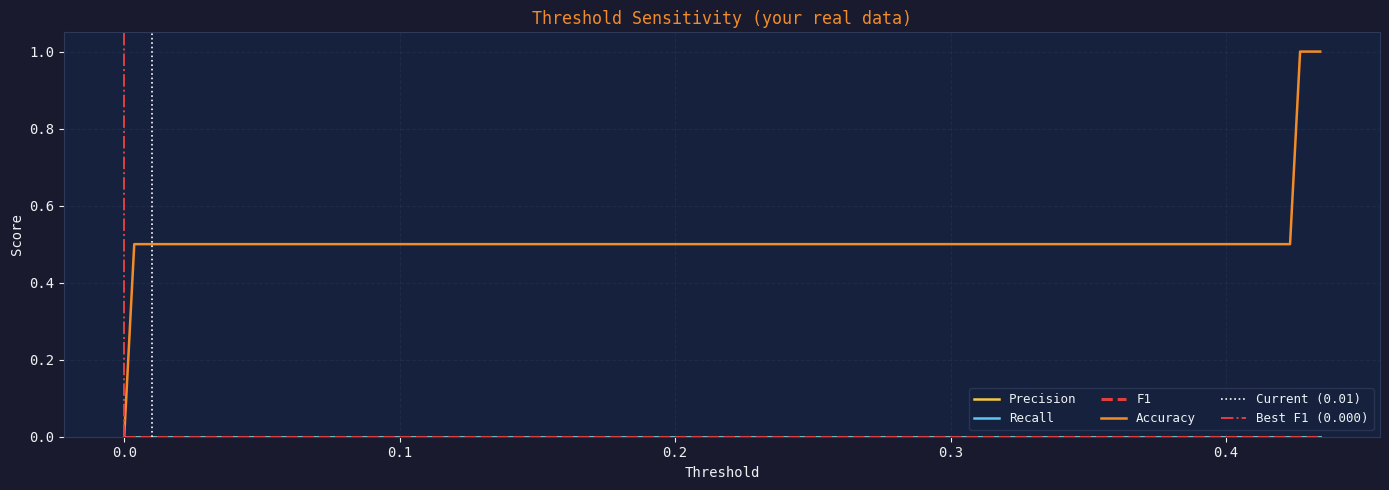

In [7]:
thresholds = np.linspace(0, max(pred_scores_arr.max()+0.01, 0.3), 120)
precs,recs,f1s,accs = [],[],[],[]

for thr in thresholds:
    preds = (pred_scores_arr >= thr).astype(int)
    tp_t  = np.sum((preds==1)&(gt_labels_arr==1))
    fp_t  = np.sum((preds==1)&(gt_labels_arr==0))
    fn_t  = np.sum((preds==0)&(gt_labels_arr==1))
    tn_t  = np.sum((preds==0)&(gt_labels_arr==0))
    p     = tp_t/(tp_t+fp_t) if (tp_t+fp_t)>0 else 0
    r     = tp_t/(tp_t+fn_t) if (tp_t+fn_t)>0 else 0
    precs.append(p); recs.append(r)
    f1s.append(2*p*r/(p+r) if (p+r)>0 else 0)
    accs.append((tp_t+tn_t)/len(gt_labels_arr))

best_thr = thresholds[np.argmax(f1s)]
print(f"✅ Best threshold for your real data: {best_thr:.4f}  (F1={max(f1s):.4f})")
print(f"   → Update THRESHOLD in Cell 3 to {best_thr:.4f} for best results")

fig2, ax = plt.subplots(figsize=(14,5), facecolor=BG_DARK)
ax.plot(thresholds,precs,color=FIRE_YLW,lw=1.8,label="Precision")
ax.plot(thresholds,recs, color="#5BC8F5",lw=1.8,label="Recall")
ax.plot(thresholds,f1s,  color=FIRE_RED, lw=2.2,linestyle="--",label="F1")
ax.plot(thresholds,accs, color=FIRE_ORG, lw=1.8,label="Accuracy")
ax.axvline(THRESHOLD, color="white",   lw=1.2,linestyle=":",  label=f"Current ({THRESHOLD})")
ax.axvline(best_thr,  color=FIRE_RED,  lw=1.4,linestyle="-.", label=f"Best F1 ({best_thr:.3f})")
ax.set(xlabel="Threshold",ylabel="Score",ylim=[0,1.05])
ax.set_title("Threshold Sensitivity (your real data)", color=FIRE_ORG, fontsize=12)
ax.legend(fontsize=9,facecolor=BG_PANEL,edgecolor=GRID_COL,ncol=3); ax.grid(True)
plt.tight_layout()
plt.savefig("fire_threshold_sweep.png",dpi=150,bbox_inches="tight",facecolor=BG_DARK)
plt.show()


## 6 · Summary

| Step | Action |
|---|---|
| More data | Capture more frames in `fire_compare_with_logging.ipynb` — more frames = more reliable metrics |
| Tune threshold | Use the **best threshold** printed above and update `THRESHOLD` in Cell 3 |
| Improve detection | Adjust HSV ranges in `detect_fire_mask` if precision/recall is low |
| Re-evaluate | Re-run this notebook after every change to see updated metrics |
